Montando drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importando as dependências

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras import regularizers
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import metrics
from typing import List

Carregando o arquivo e visualizando os dados

In [3]:
dataADT = pd.read_csv('drive/MyDrive/TEES/Autism_Dataset_for_Toddlers.csv')
dataADT.head()

,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


In [4]:
dataADT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Case_No                 1054 non-null   int64 
 1   A1                      1054 non-null   int64 
 2   A2                      1054 non-null   int64 
 3   A3                      1054 non-null   int64 
 4   A4                      1054 non-null   int64 
 5   A5                      1054 non-null   int64 
 6   A6                      1054 non-null   int64 
 7   A7                      1054 non-null   int64 
 8   A8                      1054 non-null   int64 
 9   A9                      1054 non-null   int64 
 10  A10                     1054 non-null   int64 
 11  Age_Mons                1054 non-null   int64 
 12  Qchat-10-Score          1054 non-null   int64 
 13  Sex                     1054 non-null   object
 14  Ethnicity               1054 non-null   object
 15  Jaun

Verificação de dados nulos

In [5]:
dataADT.isna().sum()

,0
Case_No,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0


Cenverter tipo da instância

In [6]:
le = LabelEncoder()
colToConvert = [
    'Class/ASD Traits ',
    'Jaundice',
    'Sex',
    'Family_mem_with_ASD'
]

for colum in colToConvert:
    dataADT[colum] = le.fit_transform(dataADT[colum])
    print(dataADT[colum].value_counts())
    print("-" * 40)

Class/ASD Traits 
1    728
0    326
Name: count, dtype: int64
----------------------------------------
Jaundice
0    766
1    288
Name: count, dtype: int64
----------------------------------------
Sex
1    735
0    319
Name: count, dtype: int64
----------------------------------------
Family_mem_with_ASD
0    884
1    170
Name: count, dtype: int64
----------------------------------------


Avaliação do modelo

In [7]:
dataADT['Ethnicity'].value_counts()

,count
Ethnicity,
White European,334
asian,299
middle eastern,188
south asian,60
black,53
Hispanic,40
Others,35
Latino,26
mixed,8


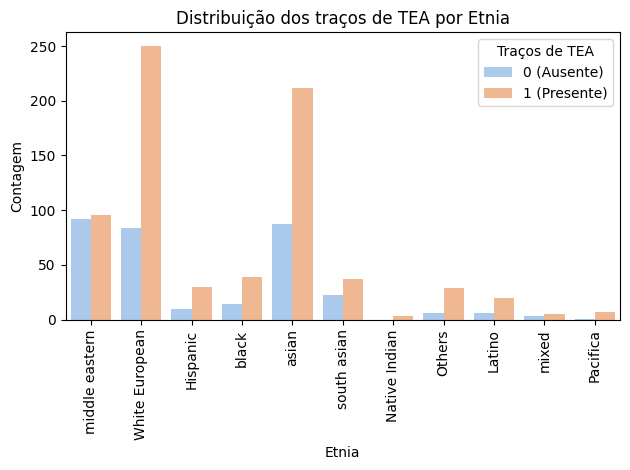

In [8]:
sns.countplot(data=dataADT, x='Ethnicity', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribuição dos traços de TEA por Etnia')
plt.xlabel('Etnia')
plt.ylabel('Contagem')
plt.xticks(rotation=90)
plt.legend(title='Traços de TEA', labels=['0 (Ausente)', '1 (Presente)'], loc='upper right')
plt.tight_layout()
plt.show()

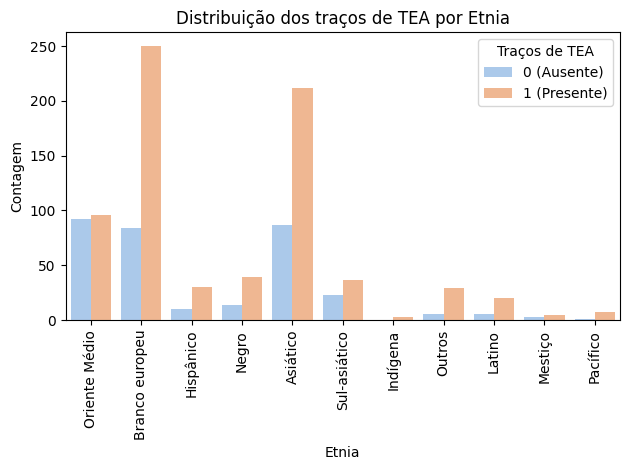

In [9]:
def normalizar(texto):
    return texto.strip().lower()

traducao = {
    'middle eastern': 'Oriente Médio',
    'white european': 'Branco europeu',
    'asian': 'Asiático',
    'hispanic': 'Hispânico',
    'black': 'Negro',
    'south asian': 'Sul-asiático',
    'asian/european': 'Asiático/Europeu',
    'others': 'Outros',
    'latino': 'Latino',
    'native indian': 'Indígena',
    'asian/other': 'Asiático/Outro',
    'mixed': 'Mestiço',
    'pacifica': 'Pacífico'
}

dataADT['Ethnicity'] = dataADT['Ethnicity'].str.strip().str.lower()
dataADT['Ethnicity'] = dataADT['Ethnicity'].map(traducao).fillna(dataADT['Ethnicity'])

ax = sns.countplot(data=dataADT, x='Ethnicity', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribuição dos traços de TEA por Etnia')
plt.xlabel('Etnia')
plt.ylabel('Contagem')
plt.xticks(rotation=90)
plt.legend(title='Traços de TEA', labels=['0 (Ausente)', '1 (Presente)'], loc='upper right')
plt.tight_layout()
plt.show()

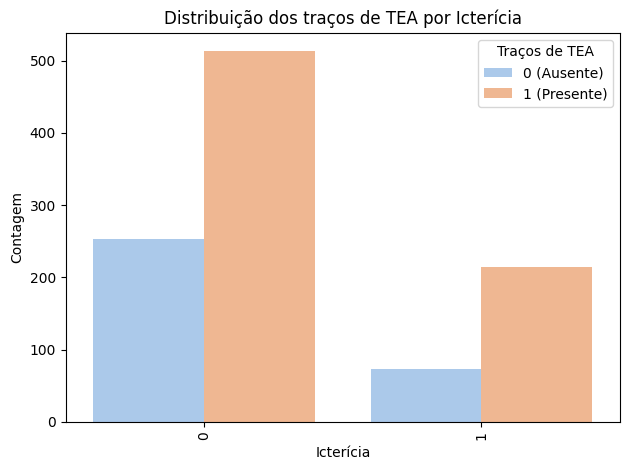

In [10]:
sns.countplot(data=dataADT, x='Jaundice', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribuição dos traços de TEA por Icterícia')
plt.xlabel('Icterícia')
plt.ylabel('Contagem')
plt.xticks(rotation=90)
plt.legend(title='Traços de TEA', labels=['0 (Ausente)', '1 (Presente)'], loc='upper right')
plt.tight_layout()
plt.show()

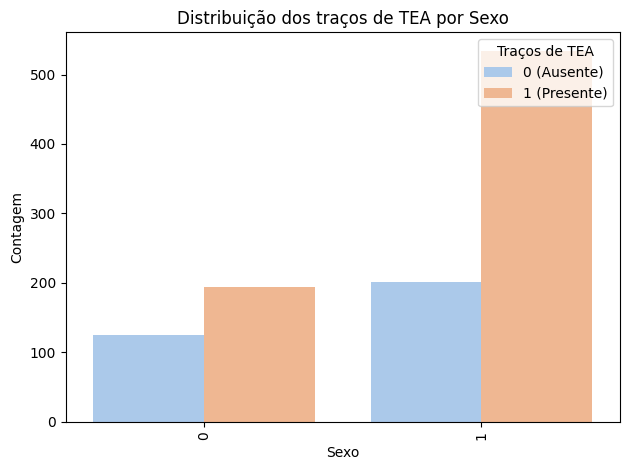

In [11]:
sns.countplot(data=dataADT, x='Sex', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribuição dos traços de TEA por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Contagem')
plt.xticks(rotation=90)
plt.legend(title='Traços de TEA', labels=['0 (Ausente)', '1 (Presente)'], loc='upper right')
plt.tight_layout()
plt.show()

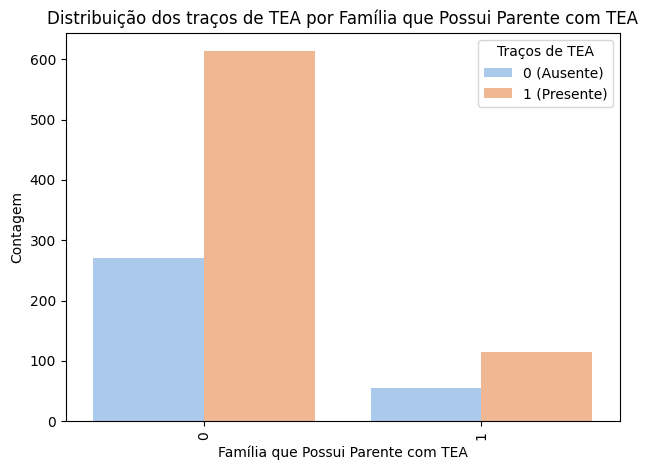

In [12]:
sns.countplot(data=dataADT, x='Family_mem_with_ASD', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribuição dos traços de TEA por Família que Possui Parente com TEA')
plt.xlabel('Família que Possui Parente com TEA')
plt.ylabel('Contagem')
plt.xticks(rotation=90)
plt.legend(title='Traços de TEA', labels=['0 (Ausente)', '1 (Presente)'], loc='upper right')
plt.tight_layout()
plt.show()

Boxplot

<Axes: >

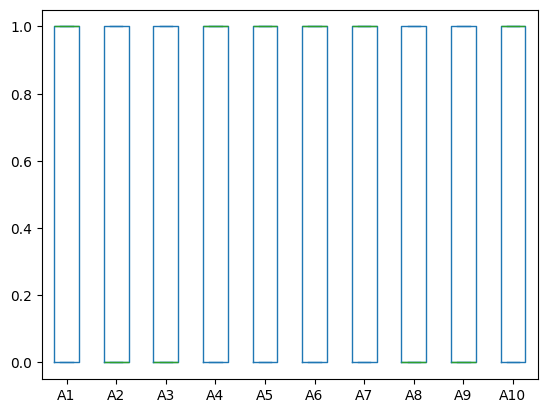

In [13]:
#separar em duas (caracteristicas comportamentais e caracteristicas individuais)
colBC = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']
dataADT[colBC].plot(kind = 'box')

<Axes: >

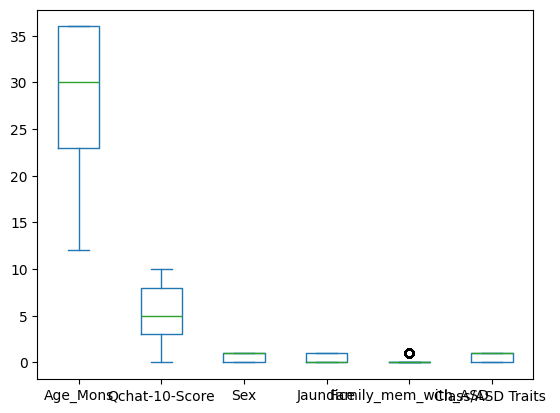

In [14]:
colIC = ['Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits ']
dataADT[colIC].plot(kind = 'box')

In [15]:
#sns.pairplot(dataADT[colBC], kind='kde')

In [16]:
#sns.pairplot(dataADT[colIC], kind='kde')

In [17]:
dataADT['Ethnicity'] = le.fit_transform(dataADT['Ethnicity'])

In [18]:
dataADT['Who completed the test'] = le.fit_transform(dataADT['Who completed the test'])

In [19]:
dataADT['Sex'] = le.fit_transform(dataADT['Sex'])

In [20]:
dataADT['Jaundice'] = le.fit_transform(dataADT['Jaundice'])

In [21]:
dataADT['Class/ASD Traits '] = le.fit_transform(dataADT['Class/ASD Traits '])

In [22]:
dataADT['Family_mem_with_ASD'] = le.fit_transform(dataADT['Family_mem_with_ASD'])

Criando modelo

In [23]:
entry = dataADT.drop('Class/ASD Traits ', axis=1)
desired_output = dataADT['Class/ASD Traits '].values

data_train, data_test, output_train, output_test = train_test_split(entry, desired_output, test_size=0.2)

In [24]:
sc = StandardScaler()
sc.fit(data_train)

data_train_standardized = sc.transform(data_train)
data_test_standardized = sc.transform(data_test)

In [25]:
classes = np.unique(output_train)
pesos_array = class_weight.compute_class_weight('balanced', classes=classes, y=output_train)
pesos_dict = dict(enumerate(pesos_array))
print("\nClass weights:", pesos_dict)


Class weights: {0: np.float64(1.6726190476190477), 1: np.float64(0.7131979695431472)}


In [26]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(units=128, activation='relu', input_shape=(data_train.shape[1],)))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Dense(units=64, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
early_stopping = EarlyStopping(monitor='val_loss', patience=15, mode='min', restore_best_weights=True)

In [28]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [29]:
historyADT = model.fit(data_train_standardized, output_train, epochs=40, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8220 - loss: 1.2429 - val_accuracy: 0.9408 - val_loss: 0.9865
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9466 - loss: 0.8873 - val_accuracy: 0.9704 - val_loss: 0.7565
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9599 - loss: 0.7143 - val_accuracy: 0.9822 - val_loss: 0.6096
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9688 - loss: 0.5790 - val_accuracy: 0.9882 - val_loss: 0.5091
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9733 - loss: 0.4897 - val_accuracy: 1.0000 - val_loss: 0.4167
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9763 - loss: 0.4117 - val_accuracy: 1.0000 - val_loss: 0.3536
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9822 - loss: 0.3453 - val_accuracy: 1.0000 - val_loss: 0.3013
Epoch 8/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9866 - loss: 0.2847 - val_accuracy: 1.0000 - val_lo

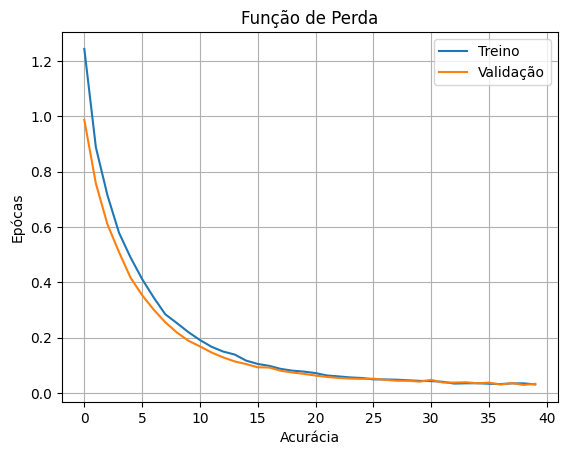

In [30]:
plt.plot(historyADT.history['loss'], label='Treino')
plt.plot(historyADT.history['val_loss'], label='Validação')
plt.title('Função de Perda')
plt.xlabel('Acurácia')
plt.ylabel('Epócas')
plt.legend()
#plt.yscale('log')
plt.grid(True)
plt.show()

In [31]:
output_proba = model.predict(data_test_standardized)

output_proba = output_proba.reshape(output_proba.shape[0])

output_pred = (output_proba > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [32]:
def model_predict(data_test_standardized):
  output_proba = model.predict(data_test_standardized)

  output_proba = output_proba.reshape(output_proba.shape[0])

  output_pred = (output_proba > 0.5).astype(int)

  return output_pred


In [33]:
from sklearn.metrics import classification_report

print(classification_report(output_test, output_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        74
           1       1.00      0.99      1.00       137

    accuracy                           1.00       211
   macro avg       0.99      1.00      0.99       211
weighted avg       1.00      1.00      1.00       211



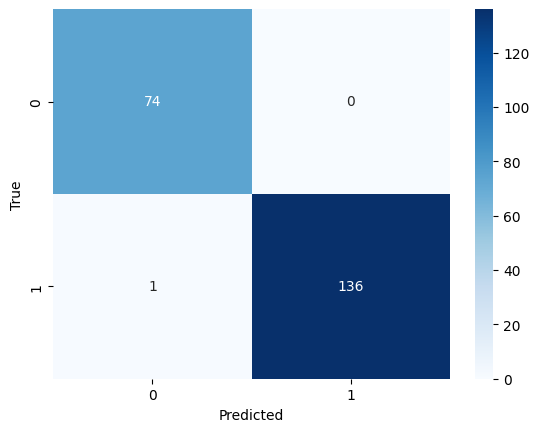

In [34]:
cm = confusion_matrix(output_test, output_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [35]:
def generate_profile(row):
  profile = []

  if row['A1'] == 1 or row['A2'] == 1:
    profile.append("social_interaction_difficulty")

  if row['A3'] == 1:
    profile.append("gestural_communication_difficulty")

  if row['A4'] == 1:
    profile.append("social_communication_difficulty")

  if row['A5'] == 1:
    profile.append("imagination_difficulty")

  if row['A6'] == 1:
    profile.append("joint_attention_difficulty")

  if row['A7'] == 1:
    profile.append("social_empathy_difficulty")

  if row['A8'] == 1:
    profile.append("atypical_language")

  if row['A9'] == 1:
    profile.append("non_verbal_communication_difficulty")

  if row['A10'] == 1:
    profile.append("atypical_attention")

  return profile

In [36]:
def recommend_strategies(profile):
  """Recommend evidence-based strategies based on specific difficulties from the dataset."""

  strategies = []

  if "social_interaction_difficulty" in profile:
    strategies.extend([
        "Posicionar-se na altura dos olhos da criança",
        "Utilizar objetos atrativos para direcionar o olhar",
        "Reforçar contato visual e resposta ao chamado"
  ])

  if "gestural_communication_difficulty" in profile:
    strategies.extend([
        "Imitação adulta e atenção compartilhada para promover gestos",
        "Criação de oportunidades para a criança responder espontaneamente com gestos funcionais",
        "Integração de gestos para apoiar a linguagem",
        "Adaptação às características únicas de cada criança"
  ])

  if "social_communication_difficulty" in profile:
    strategies.extend([
        "Ensino de saudações por meio de role-play",
        "Solicitações claras e educadas utilizando diferentes formas de frases, tom expressivo e gestos",
        "Modelar cumprimentos em formato lúdico",
        "Integração das atividades às rotinas diárias para promover a generalização das habilidades"
    ])

  if "imagination_difficulty" in profile:
    strategies.extend([
        "Utilizar ambientes temáticos multi-sensoriais para engajar a imaginação",
        "Recursos para estimular comportamentos imaginativos",
        "Estruturar brincadeiras com a liderança da criança, para facilitar o engajamento imaginativo"
    ])

  if "joint_attention_difficulty" in profile:
    strategies.extend([
        "Usar um recipiente fechado com objetos surpresa",
        "Modelar o foco e diversão com expressões faciais e linguagem corporal, usando apenas palavras-chave"
    ])

  if "social_empathy_difficulty" in profile:
    strategies.extend([
        "Usar cartões de emoção e histórias sociais para ensinar emoções básicas",
        "Videomodelagem e roteiros sociais para demonstrar expressões emocionais",
        "Atividades de tomada de perspectiva para compreender o ponto de vista do outro"
    ])

  if "atypical_language" in profile:
    strategies.extend([
        "Utilizar aprendizado baseado em jogos e lúdico para ensinar comunicação verbal via estimulação sensorial",
        "Usar itens domésticos com instrução personalizada para criar um ambiente interativo que auxilia no reconhecimento de pistas sociais e na regulação de respostas",
    ])

  if "non_verbal_communication_difficulty" in profile:
    strategies.extend([
        "Jogos de adivinhação de emoções",
        "Utilizar espelho para praticar expressões",
        "Jogos de imitação"
    ])

  if "atypical_attention" in profile:
    strategies.extend([
        "Usar interesses especiais como motivadores",
        "Rotinas consistentes",
        "Dividir tarefas com pausas programadas",
        "Promoção de estados de fluxo"
     ])

  return list(set(strategies))

In [37]:
def define_level(prob: float) -> str:
  """Define support level based on probability score."""
  if prob > 0.8:
    return "high support"
  if prob > 0.5:
    return "moderate support"
  return "low support"

In [38]:
def educational_system(model, scaler, input_df):
  input_scaled = scaler.transform(input_df)

  proba = model.predict(input_scaled)
  pred = (proba > 0.5).astype(int)

  results = []
  for i, (idx, row) in enumerate(input_df.iterrows()):
    profile = generate_profile(row)

    results.append({
        "autism_probability": float(proba[i][0]),
        "model_prediction": int(pred[i][0]),
        "support_level": define_level(proba[i][0]),
        "profile": profile,
        "recommended_strategies": recommend_strategies(profile)
    })

  return results

In [39]:
single_example = data_test.iloc[0:1]
single_result = educational_system(model, sc, single_example)
print("Single Sample Result:", single_result)

multiple_examples = data_test.iloc[0:5]
multiple_results = educational_system(model, sc, multiple_examples)

for i, result in enumerate(multiple_results):
    print(f"\n--- Sample {i+1} ---")
    print(f"Probability: {result['autism_probability']:.4f}")
    print(f"Prediction: {result['model_prediction']}")
    print(f"Support Level: {result['support_level']}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Single Sample Result: [{'autism_probability': 9.472293459111825e-05, 'model_prediction': 0, 'support_level': 'low support', 'profile': ['social_interaction_difficulty'], 'recommended_strategies': ['Utilizar objetos atrativos para direcionar o olhar', 'Posicionar-se na altura dos olhos da criança', 'Reforçar contato visual e resposta ao chamado']}]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

--- Sample 1 ---
Probability: 0.0001
Prediction: 0
Support Level: low support

--- Sample 2 ---
Probability: 0.0000
Prediction: 0
Support Level: low support

--- Sample 3 ---
Probability: 1.0000
Prediction: 1
Support Level: high support

--- Sample 4 ---
Probability: 0.0010
Prediction: 0
Support Level: low support

--- Sample 5 ---
Probability: 0.9980
Prediction: 1
Support Level: high support


In [40]:
example = data_test.iloc[0:1]

result = educational_system(model, sc, example)

print("Result:", result)
print("\nAutism Probability:", result[0]["autism_probability"])
print("Model Prediction:", result[0]["model_prediction"])
print("Support Level:", result[0]["support_level"])
print("Profile:", result[0]["profile"])
print("Recommended Strategies:", result[0]["recommended_strategies"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Result: [{'autism_probability': 9.472293459111825e-05, 'model_prediction': 0, 'support_level': 'low support', 'profile': ['social_interaction_difficulty'], 'recommended_strategies': ['Utilizar objetos atrativos para direcionar o olhar', 'Posicionar-se na altura dos olhos da criança', 'Reforçar contato visual e resposta ao chamado']}]

Autism Probability: 9.472293459111825e-05
Model Prediction: 0
Support Level: low support
Profile: ['social_interaction_difficulty']
Recommended Strategies: ['Utilizar objetos atrativos para direcionar o olhar', 'Posicionar-se na altura dos olhos da criança', 'Reforçar contato visual e resposta ao chamado']


In [41]:
print(model.predict(data_test_standardized[:10]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[9.4722942e-05]
 [3.7749501e-06]
 [9.9999863e-01]
 [1.0203780e-03]
 [9.9800718e-01]
 [3.3432607e-02]
 [9.9999988e-01]
 [3.7602658e-05]
 [9.9996388e-01]
 [1.5268971e-04]]


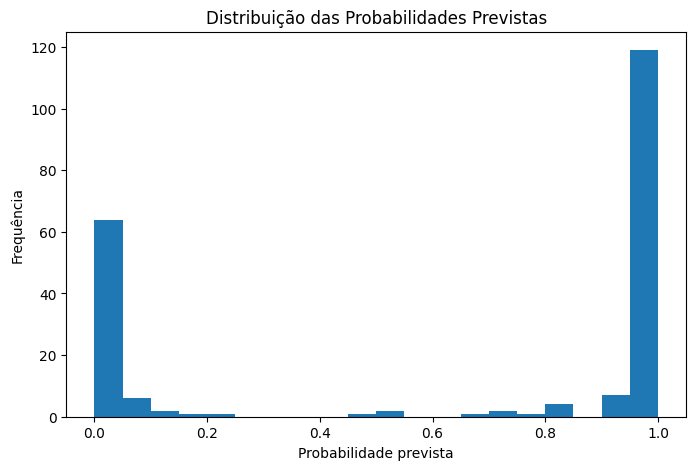

In [42]:
plt.figure(figsize=(8,5))
plt.hist(output_proba, bins=20)
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência")
plt.title("Distribuição das Probabilidades Previstas")
plt.show()

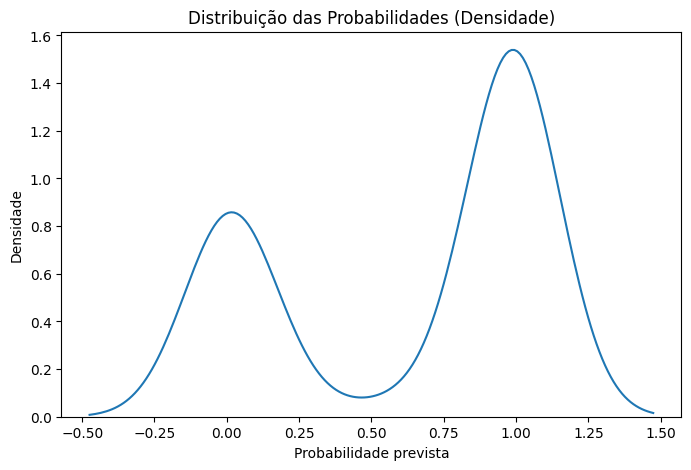

In [43]:
plt.figure(figsize=(8,5))
sns.kdeplot(output_proba)
plt.xlabel("Probabilidade prevista")
plt.ylabel("Densidade")
plt.title("Distribuição das Probabilidades (Densidade)")
plt.show()

<Axes: >

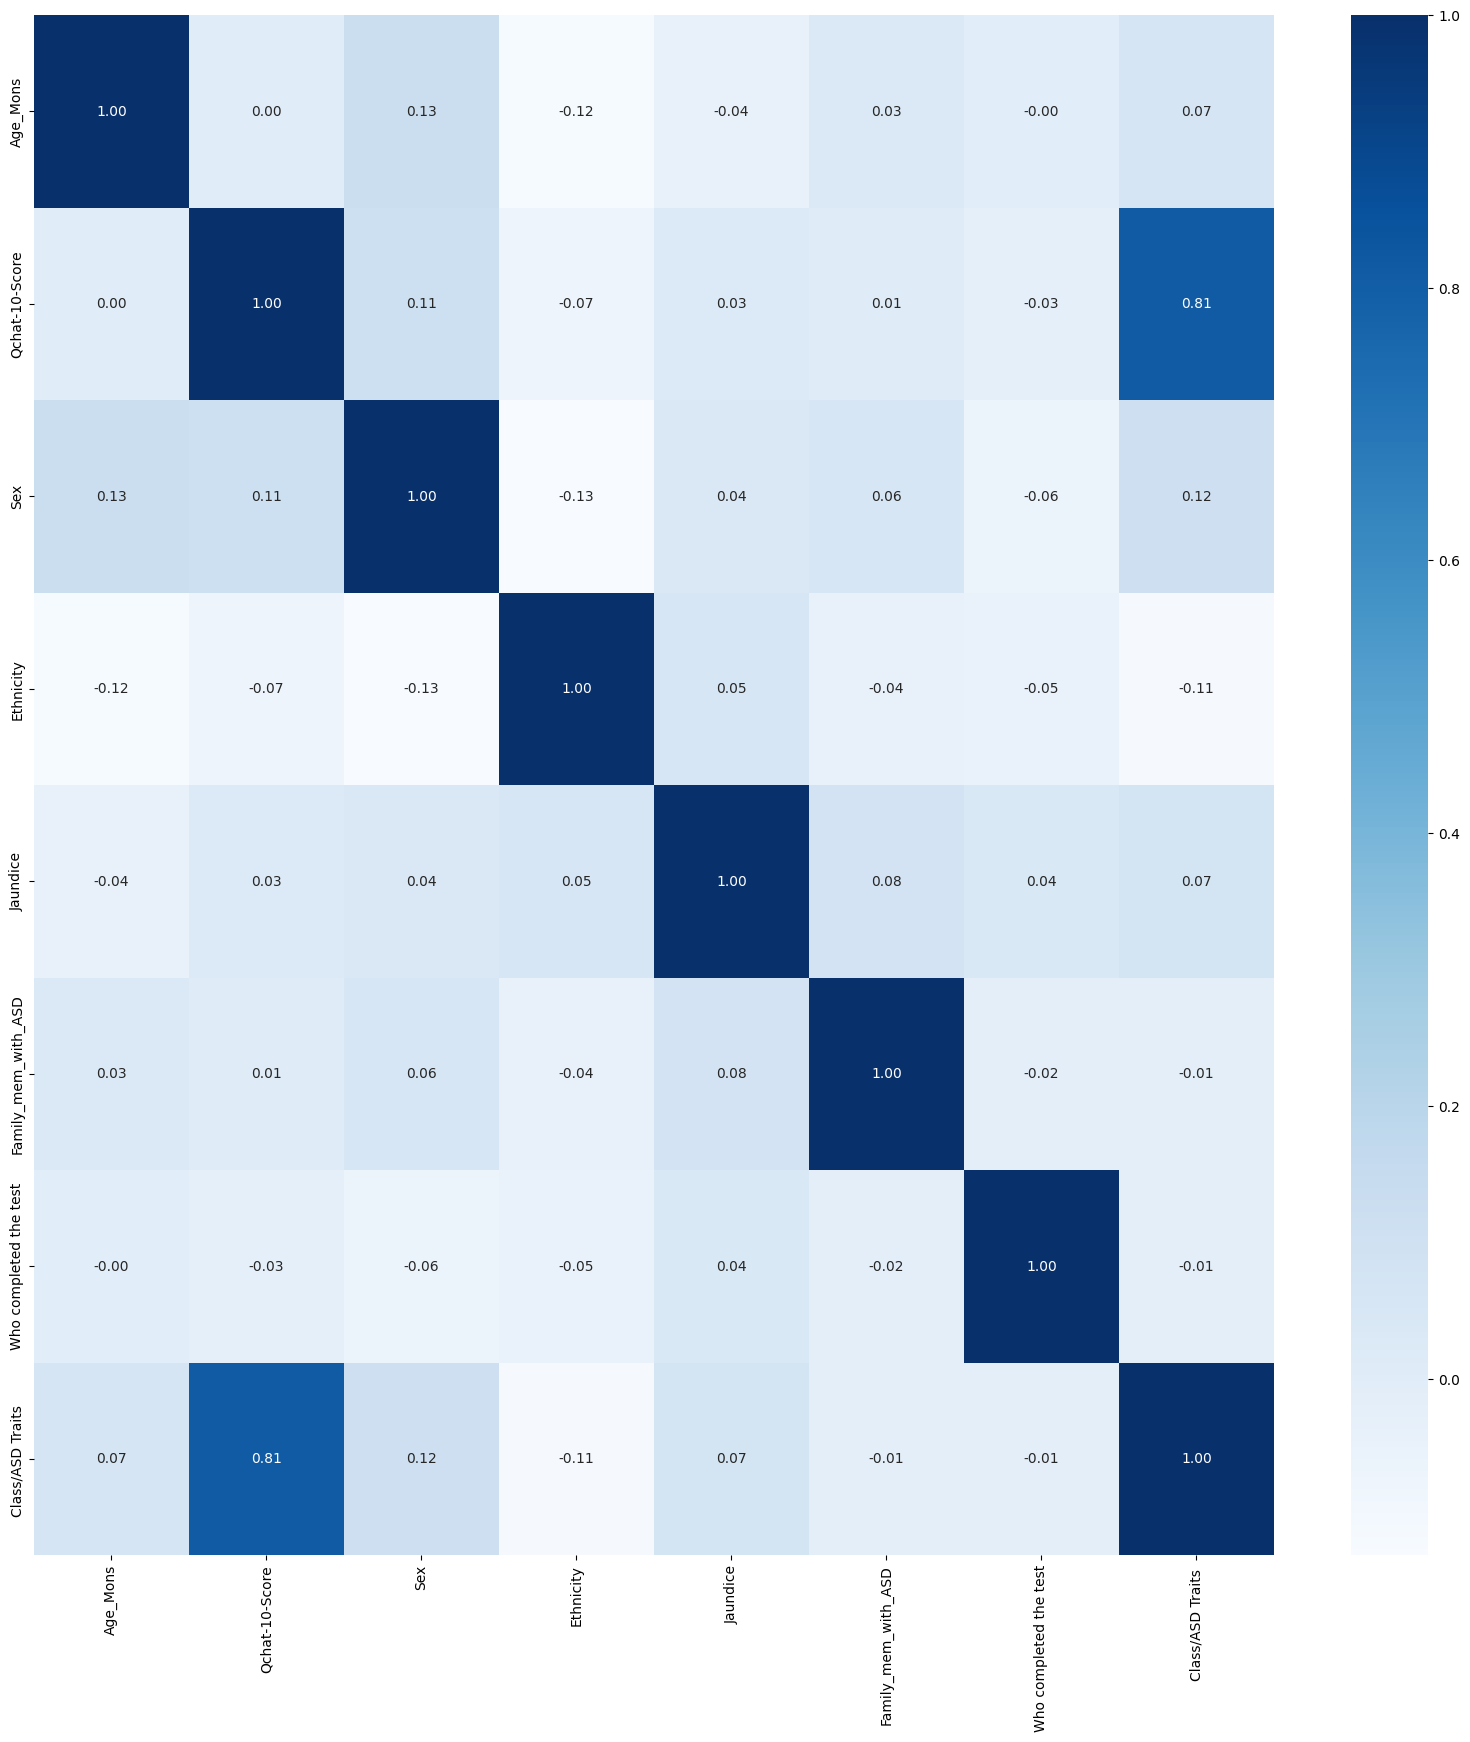

In [44]:
attributes = ['Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits ']
corr = dataADT[attributes].corr()
plt.figure(figsize = (20,20))

sns.heatmap(corr, annot=True, fmt=".2f", cmap='Blues')

In [45]:
print(dataADT['Class/ASD Traits '].value_counts())


Class/ASD Traits 
1    728
0    326
Name: count, dtype: int64


In [46]:
data_train.shape

(843, 18)

In [47]:
pd.Series(output_train).value_counts()

,count
1,591
0,252


In [48]:
!pip install shap

IA EXPLICÁVEL

In [49]:
import shap

In [50]:
explainer = shap.KernelExplainer(model_predict, data_train_standardized)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [51]:
len(data_test_standardized)

211

In [52]:
shap_values = explainer.shap_values(data_test_standardized[0:10])

  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
54901/54901 ━━━━━━━━━━━━━━━━━━━━ 81s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
54901/54901 ━━━━━━━━━━━━━━━━━━━━ 67s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
54901/54901 ━━━━━━━━━━━━━━━━━━━━ 65s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
54901/54901 ━━━━━━━━━━━━━━━━━━━━ 67s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
54901/54901 ━━━━━━━━━━━━━━━━━━━━ 70s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
54901/54901 ━━━━━━━━━━━━━━━━━━━━ 68s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
54901/54901 ━━━━━━━━━━━━━━━━━━━━ 67s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
54901/54901 ━━━━━━━━━━━━━━━━━━━━ 69s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
54901/54901 ━━━━━━━━━━━━━━━━━━━━ 65s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
54901/54901 ━━━━━━━━━━━━━━━━━━━━ 65s 1ms/step


In [53]:
shap_values

array([[ 0.        ,  0.        , -0.05631111, -0.03526693, -0.054077  ,
        -0.05463998, -0.06216429, -0.08304084, -0.05127097, -0.05689698,
        -0.05205514,  0.        , -0.19534439,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 0.        , -0.05949262, -0.0540066 ,  0.        , -0.06202873,
        -0.0571143 , -0.06231469, -0.08049575, -0.04880091, -0.05282314,
        -0.04946281,  0.        , -0.17452808,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.0227383 ,  0.0295396 ,  0.        ,  0.02533148,
         0.02506307,  0.0252538 ,  0.0277341 ,  0.02512535,  0.02925725,
         0.01301199,  0.        ,  0.07587744,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 0.        , -0.06086186, -0.05571218, -0.03543361, -0.07024314,
         0.        , -0.08265753, -0.09658587, -0.04144358, -0.07538431,
         0.        ,  0.        , -0.16556504,  0.   

In [54]:
colNames = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10','Idade', 'Pontuação do questionário', 'Sexo', 'Etnia', 'Icterícia', 'Membro da família com TEA', 'Quem completou o teste', 'Traços de TEA']

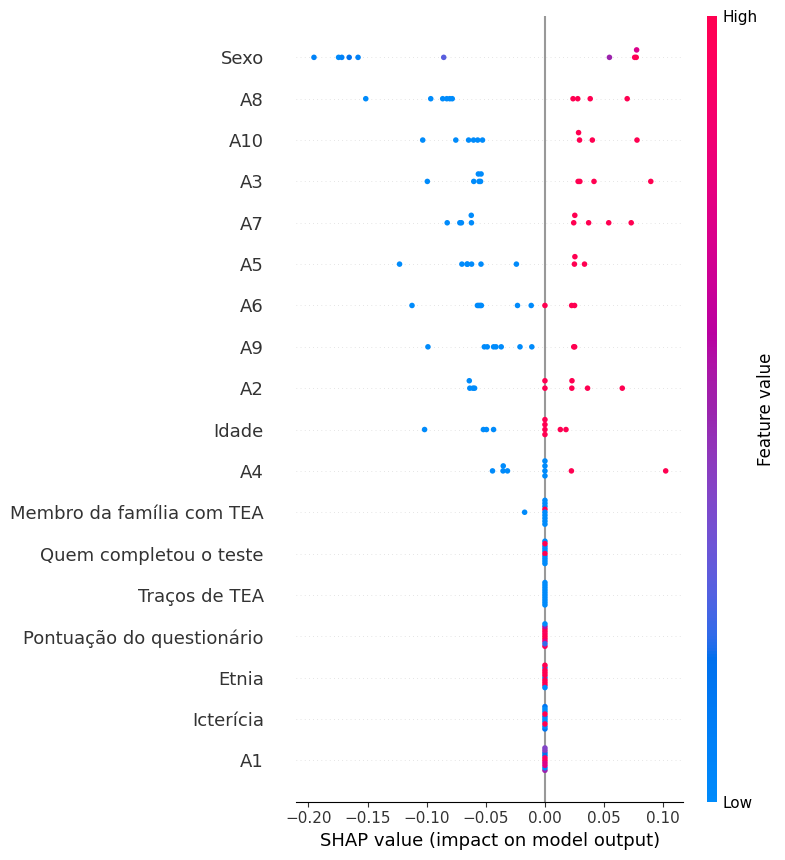

In [55]:
shap.summary_plot(shap_values, data_test_standardized[0:10], feature_names=colNames)

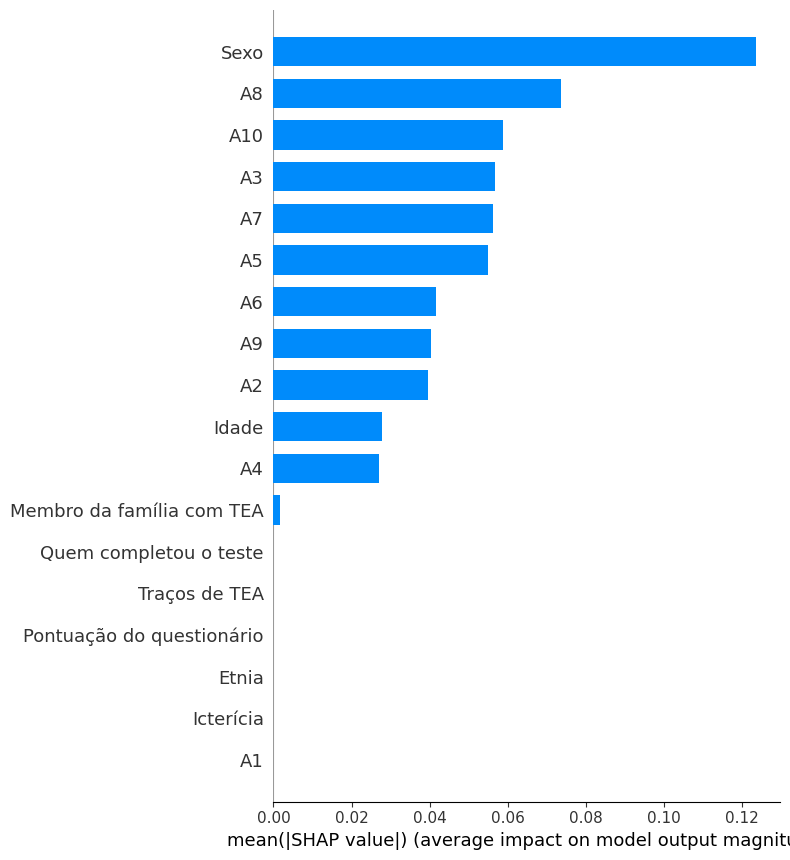

In [56]:
shap.summary_plot(shap_values, data_test_standardized, feature_names=colNames, plot_type="bar")

In [57]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values, data_test_standardized)

In [58]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3699654f49a8f342a953d7e64d0f1eb415d731c8b86d05365ab65855fa286d8e
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [59]:
import lime.lime_tabular

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=data_train_standardized,
    feature_names= colNames,
    class_names=['0', '1'],
    mode='classification',
    training_labels=output_train
)

def predict_fn(x):
    prob_class1 = model.predict(x, verbose=0)
    prob_class0 = 1 - prob_class1
    return np.hstack([prob_class0, prob_class1])

exp = explainer_lime.explain_instance(data_test_standardized[i], predict_fn)
exp.show_in_notebook(show_table=True)